# Computing the design gradient with `jaxopt`

This notebook illustrates the mechanism behind co-optimizing a structure's
design together with a sensing neural network -- it is **not** the real
production co-optimization code (that isn't distributed), but a small,
faithful illustration of how the pieces fit together, built entirely from
the modular `forward_simulation/` package and `neural_networks.py` also used
elsewhere in this repository.

The idea is a **bilevel optimization**:
- *Inner problem*: for a fixed structure design, train a CNN to read out the
  applied force from simulated sensor data.
- *Outer problem*: adjust the structure's design parameters to make that
  trained CNN's test loss as small as possible.

Differentiating the outer loss with respect to the design means
differentiating *through* the inner training loop. `jaxopt` does this via
implicit differentiation (the implicit function theorem applied to the inner
problem's optimality condition) rather than unrolling every inner step, which
is what `implicit_diff=True` below enables.

To keep this runnable in a few minutes, the structure, sample count, and
iteration counts here are all much smaller than a real optimization run.

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
from jax.tree_util import Partial
from jaxopt import OptaxSolver, linear_solve

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
DATA_DIR = PROJECT_ROOT / "data"

from forward_simulation.structures import build_input_source_2
from forward_simulation.solver import build_forward_problem
from blockymetamaterials.plotting_input import plot_geometry
from neural_networks import TimeSeriesCNN, minmax_scaler

# Default setting
import matplotlib as mpl
import matplotlib
from matplotlib import cm
from cycler import cycler

# mpl.rcParams['axes.prop_cycle'] = cycler(color='brgcmyk')
# grid setting
plt.rcParams['axes.grid'] = False
plt.rcParams['grid.color'] = '#808080'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.5

# graph font size
# mpl.rcParams['font.size'] = 16
mpl.rcParams['legend.fontsize'] = 16
mpl.rcParams['figure.titlesize'] = 18
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 14
mpl.rcParams['ytick.labelsize'] = 14

# tight axis
plt.rcParams['axes.xmargin'] = 0

# figure size
plt.rcParams["figure.figsize"] = (6.4, 4.8)

# LaTeX
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['pdf.fonttype'] = 42 # For TrueType fonts

COLORS = ["#cc3f40", "#bdccd4", "#0b2456", "#2980b9", "#00a043"]

## Setup: structure, a small force dataset, and the flattened design vector

The design is the pair of (horizontal, vertical) node-shift arrays; for
differentiation and optimization it gets flattened into a single vector
`meta_params`, the same convention the original co-optimization scripts use.

In [2]:
structure = build_input_source_2()
forward_problem = build_forward_problem(structure)
run_batch = jax.vmap(forward_problem, in_axes=(None, 0))

# A handful of real force samples from the co-optimization dataset. Sampled
# randomly rather than taken in order, since the dataset is grouped by which
# input source is active and a naive slice can accidentally pick up a
# constant (zero-variance) force channel.
data = np.load(DATA_DIR / "forward_sim_input_source_2.npz")
rng = np.random.RandomState(1)
sample_idx = rng.choice(data["output_data"].shape[0], 8, replace=False)
output_data = jnp.asarray(data["output_data"][sample_idx])
print("output_data (force):", output_data.shape)

h0, v0 = structure.initial_design
hori_len = h0.size
meta_params0 = jnp.concatenate([h0.flatten(), v0.flatten()])
print("meta_params (flattened design):", meta_params0.shape)


def unflatten(meta_params):
    h = meta_params[:hori_len].reshape(h0.shape)
    v = meta_params[hori_len:].reshape(v0.shape)
    return h, v

output_data (force): (8, 200, 2)
meta_params (flattened design): (98,)


## Inner problem: train a CNN for a fixed design

`inner_loss` is the CNN's training loss. `inner_solver` trains it with Adam;
`implicit_diff=True` is what makes the *result* of this training
differentiable with respect to `meta_params` (passed through as the second
argument, jaxopt's convention for the parameters the implicit-diff solve
should differentiate against) without unrolling every Adam step.

In [3]:
model = TimeSeriesCNN(output_features=output_data.shape[-1])


def inner_loss(params, meta_params, data):
    x, y = data
    pred = model.apply(params, x)
    return jnp.mean((pred - y) ** 2)


inner_solver = OptaxSolver(
    opt=optax.adam(1e-2),
    fun=inner_loss,
    maxiter=20,
    implicit_diff=True,
    implicit_diff_solve=Partial(linear_solve.solve_cg, maxiter=10, tol=1e-7),
)

## Outer problem: how good is the trained CNN for this design?

`outer_loss(meta_params)` re-runs the forward physics simulation for the
current design (via the same `forward_simulation` module used in the other
notebooks), trains a fresh CNN on it via `inner_solver.run(...)`, and returns
its held-out test loss. Because the forward simulation and the inner solve
are both plain JAX code, `outer_loss` is itself differentiable end to end.

In [4]:
test_idx = jnp.arange(2)
train_mask = jnp.ones(output_data.shape[0], dtype=bool).at[test_idx].set(False)
key = jax.random.PRNGKey(0)


def outer_loss(meta_params):
    design = unflatten(meta_params)
    input_data = run_batch(design, output_data)  # forward simulation, differentiable w.r.t. design

    train_x, train_y = input_data[train_mask], output_data[train_mask]
    test_x, test_y = input_data[test_idx], output_data[test_idx]
    scaler = minmax_scaler(train_x, train_y)
    train_xn, train_yn = scaler.transform(train_x, train_y)
    test_xn, test_yn = scaler.transform(test_x, test_y)

    nn_params = model.init(key, train_xn)
    params_sol, state = inner_solver.run(nn_params, meta_params, (train_xn, train_yn))

    pred = model.apply(params_sol, test_xn)
    loss = jnp.mean((pred - test_yn) ** 2)
    return loss, (params_sol, state)

## The gradient itself

The first call below is slow (JAX is tracing and compiling the whole forward
simulation + inner training loop + implicit-diff backward pass); later calls
reuse the compiled program and are much faster.

In [5]:
t0 = time.time()
(loss_val, aux), grad = jax.value_and_grad(outer_loss, has_aux=True)(meta_params0)
print(f"outer loss: {loss_val:.4e}")
print(f"gradient shape: {grad.shape}, norm: {jnp.linalg.norm(grad):.4e}")
print(f"(compile + run took {time.time() - t0:.1f}s)")

(1, 1, 3) (1, 1, 3)
(1, 1, 2) (1, 1, 2)


outer loss: 2.6303e-02


gradient shape: (98,), norm: 3.2118e-01
(compile + run took 19.3s)


## Updating the design: the outer optimization loop

In the original scripts this is wrapped in a second `OptaxSolver`, whose
`.update()` call does exactly the gradient computation above plus one Adam
step, in a plain Python loop over outer iterations.

In [6]:
outer_solver = OptaxSolver(opt=optax.adam(0.05), fun=outer_loss, maxiter=5, has_aux=True)
outer_state = outer_solver.init_state(meta_params0)

meta_params = meta_params0
design_record = [meta_params]
outer_losses = []

t0 = time.time()
for i in range(outer_solver.maxiter):
    meta_params, outer_state = outer_solver.update(meta_params, outer_state)
    design_record.append(meta_params)
    outer_losses.append(float(outer_state.value))
    print(f"outer iter {i}: loss {outer_state.value:.4e}  ({time.time() - t0:.1f}s elapsed)")

(1, 1, 3) (1, 1, 3)
(1, 1, 2) (1, 1, 2)


(1, 1, 3) (1, 1, 3)
(1, 1, 2) (1, 1, 2)


outer iter 0: loss 2.6303e-02  (8.4s elapsed)


outer iter 1: loss 3.6986e-02  (10.2s elapsed)


outer iter 2: loss 3.4417e-02  (12.1s elapsed)


outer iter 3: loss 3.1560e-02  (14.0s elapsed)


outer iter 4: loss 3.2356e-02  (15.9s elapsed)


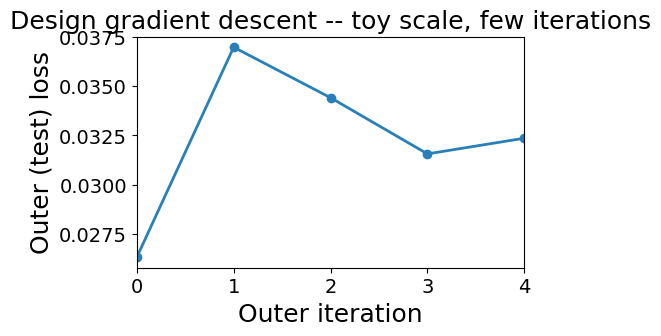

design change over 5 outer iterations: 1.1857


In [7]:
plt.figure(figsize=(5, 3))
plt.plot(outer_losses, marker="o", color=COLORS[3])
plt.xlabel("Outer iteration")
plt.ylabel("Outer (test) loss")
plt.title("Design gradient descent -- toy scale, few iterations")
plt.show()
print(f"design change over {outer_solver.maxiter} outer iterations: {jnp.linalg.norm(design_record[-1] - design_record[0]):.4f}")

## Design before vs. after

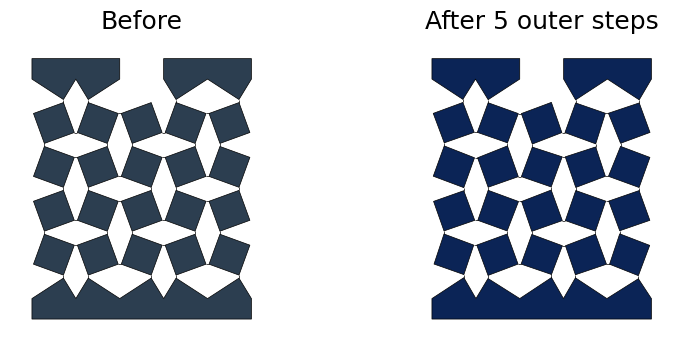

In [8]:
geometry = structure.geometry
fig, axes = plt.subplots(1, 2, figsize=(8, 3.4), constrained_layout=True)
for ax, params, title, color in zip(
    axes, [design_record[0], design_record[-1]], ["Before", f"After {outer_solver.maxiter} outer steps"], ["#2c3e50", "#0b2456"],
):
    h, v = unflatten(params)
    xlim, ylim = geometry.get_xy_limits(h, v) + 0.5 * geometry.spacing * jnp.array([-1, 1])
    plot_geometry(
        block_centroids=geometry.block_centroids(h, v),
        centroid_node_vectors=geometry.centroid_node_vectors(h, v),
        bond_connectivity=geometry.bond_connectivity(),
        xlim=xlim, ylim=ylim, ax=ax, color=color,
    )
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)
plt.show()